# Predictor layers

*SPDX-FileCopyrightText: © 2026 Nina Preußler <nina.preussler@studserv.uni-leipzig.de>*

*SPDX-License-Identifier: CC BY 4.0*

In this notebook, we prepare the layers of the predictors later used for Random Forest modeling of post-fire vegetation recovery. We load the data, process it if necessary, and align it with the study area grid created in a previous notebook.

We include the following predictors:
- the 2-month and 2-year median [pre-fire EVI](#Pre-fire-EVI)
- the fire history

## Preparation

In [8]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
from rasterio.enums import Resampling
import numpy as np
import glob
import matplotlib.pyplot as plt

In [2]:
from custom_functions import sel_bounds

In [3]:
study_area = rxr.open_rasterio('output-data/study-area/study_area.tif').squeeze()                           

## Pre-fire EVI

5-year pre-fire median EVI from MODIS obtained via GEE
- composite smoothes outliers and low quality
- already created in `2_vegetation_recovery_metrics.ipynb`

## Fire history

This layer indicates fire frequency, measured as the total number of fires in a given pixel between 2001 (start of the MODIS fire alerts dataset) and July 2015 (before our fire season).

For this purpose, we only used fire alerts with confidence > 70%, as defined in the first notebook.

In [4]:
# load fire alert points until July 2015 (created and exported in 1_study_area.ipynb)
fires_before = gpd.read_file('output-data/fire-alerts/fire_alerts_before.shp')

In [5]:
from rasterio import features
from rasterio.enums import MergeAlg

# project to metric CRS
fires_proj = fires_before.to_crs("EPSG:3857")

# buffer 500 m
fires_proj["geometry"] = fires_proj.buffer(500, cap_style='square')

# back to study CRS
fires_buffered = fires_proj.to_crs(study_area.rio.crs)

transform = study_area.rio.transform()
out_shape = study_area.rio.shape

# rasterize all at once and SUM overlaps
fire_count_array = features.rasterize(
    ((geom, 1) for geom in fires_buffered.geometry),
    out_shape=out_shape,
    transform=transform,
    all_touched=True, # any time pixel is touched by a buffer count as burn
    merge_alg=MergeAlg.add,
    dtype="uint16"
)

# make into xarray array
fire_count = xr.DataArray(
    fire_count_array,
    dims=["y", "x"],
    coords={"y": study_area.y, "x": study_area.x},
)

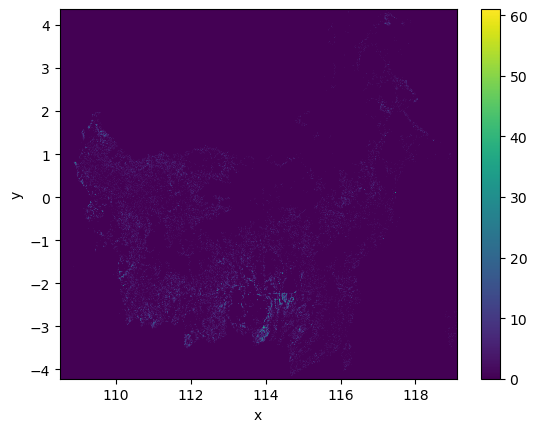

In [9]:
fire_count.plot()
plt.show()

In [10]:
# export
fire_count.rio.to_raster('output-data/predictor-layers/fire_count.tif')

## Distance to intact forest

In [17]:
# load forest data (exported from 1_study_area_identification.ipynb)
forest = rxr.open_rasterio('output-data/forest/forest_2015.tif').squeeze()

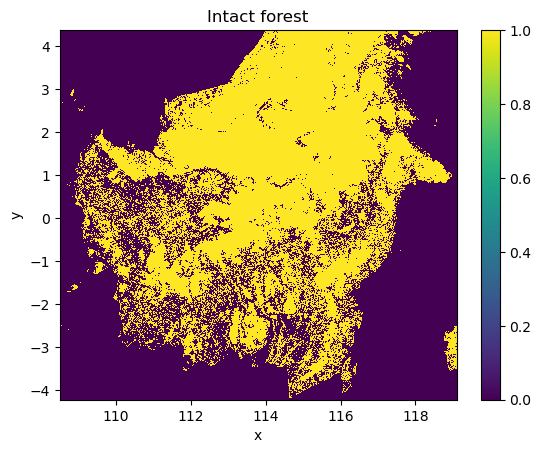

In [23]:
# filter for forest that did not burn again and had not burned before
burned_again = rxr.open_rasterio('output-data/burned_again.tif').squeeze()

forest_intact = xr.where(
    (burned_again == 0) & (fire_count == 0) & (forest == 1),
    1, 0)

forest_intact.plot()
plt.title('Intact forest')
plt.show()

In [24]:
# set values inside study area to 0 (because they will no longer be intact forest after the fires)
forest_no_study_area = xr.where(study_area == 1, 0, forest_intact)

# reproject to CRS in m (Pseudo-Mercator) for distance calculation
forest_no_study_area_reproj = forest_no_study_area.rio.write_crs(4326).rio.reproject(3857, 
                                                                                     resampling=Resampling.nearest)

In [25]:
from scipy.ndimage import distance_transform_edt

# compute distance raster (meters)
pixel_size = abs(forest_no_study_area_reproj.rio.resolution()[0])
dist = distance_transform_edt(forest_no_study_area_reproj.values == 0) * pixel_size

# bring values into array format
dist_da = xr.DataArray(
    dist,
    coords=forest_no_study_area_reproj.coords,
    dims=forest_no_study_area_reproj.dims
).rio.write_crs(forest_no_study_area_reproj.rio.crs)

In [27]:
# reproject back to 4326
forest_dist = dist_da.rio.write_crs(3857).rio.reproject_match(
    study_area,
    resampling=Resampling.bilinear)

In [31]:
# export 
forest_dist.rio.to_raster('output-data/predictor-layers/forest-dist.tif')

In [28]:
# mask with study area
forest_dist_study_area = xr.where(study_area == 1, forest_dist, np.nan).rio.write_crs(4326)

## Distance to drainage channels

used as a proxy for water table depth (closer to drainage channel means lower water table)

using raster files of drainage canals in Southeast Asia from XXX (link)

In [33]:
# build virtual raster from multiple files
!gdalbuildvrt input-data/drainage-canals/drainage_canals.vrt $(find input-data/drainage-canals -name "*.tif")                                                               

0...10...20...30...40...50...60...70...80...90...100 - done.


This virtual raster was then imported into QGIS where it was masked with the (vectorized) study area, and coarsened from a 5 to a 50 m spatial resolution using maximum resampling (if at least one canal pixel in 50m, classify 50m pixel as canal). QGIS was used because this step was too computationally expensive for Jupyter notebooks.

In [34]:
# load resampled and data
drainage_50m = rxr.open_rasterio('input-data/drainage_canals_50m.tif')

In [35]:
from scipy.ndimage import distance_transform_edt

# compute distance raster (meters) - raster already in Pseudo Mercator (CRS in m)
pixel_size = abs(drainage_50m.rio.resolution()[0])
dist = distance_transform_edt(drainage_50m.values == 0) * pixel_size

# bring values into array format
dist_da = xr.DataArray(
    dist,
    coords=drainage_50m.coords,
    dims=drainage_50m.dims
).rio.write_crs(drainage_50m.rio.crs)

In [23]:
# set values above 10000 (10km) to 10000 (higher distance doesn't make hydrological difference anymore)
# dist_da = xr.where(dist_da > 10000, 10000, dist_da).rio.write_crs(drainage_50m.rio.crs)

In [37]:
# reproject
dist_da_reproj = dist_da.rio.reproject_match(
    study_area, # project to EPSG 4326 with resolution 250m
    resampling=Resampling.average) # 250m pixel will have average value of 50m pixels it contains

In [38]:
# export 
dist_da_reproj.rio.to_raster('output-data/predictor-layers/drainage-dist.tif')

## Aridity index

In [41]:
# load data
global_aridity = rxr.open_rasterio('input-data/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif')

In [43]:
# crop 
aridity = sel_bounds(global_aridity, study_area)

# apply scale factor to obtain correct units
aridity = aridity * 0.0001

# reproject
aridity_reproj = aridity.rio.reproject_match(
    study_area,
    resampling=Resampling.bilinear) # upscaling

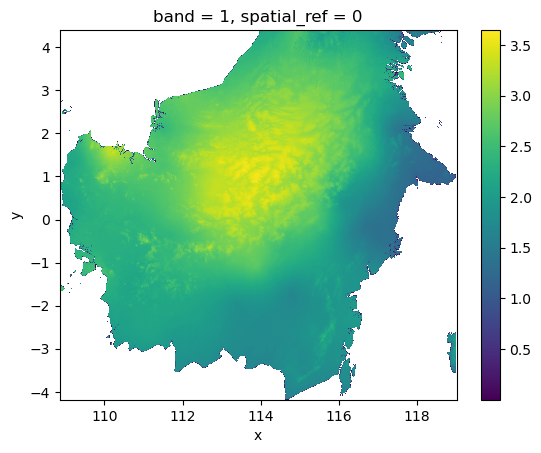

In [16]:
xr.where(aridity == 0, np.nan, aridity).plot()

In [85]:
# export
aridity_reproj.rio.to_raster('output-data/predictor-layers/aridity_index.tif')

## Human footprint

In [46]:
# load
hfp = rxr.open_rasterio('input-data/hfp2013_merisINT.tif')

In [47]:
# reproject match study area
hfp_kalimantan = hfp.rio.reproject_match(
    study_area,
    resampling=Resampling.nearest)

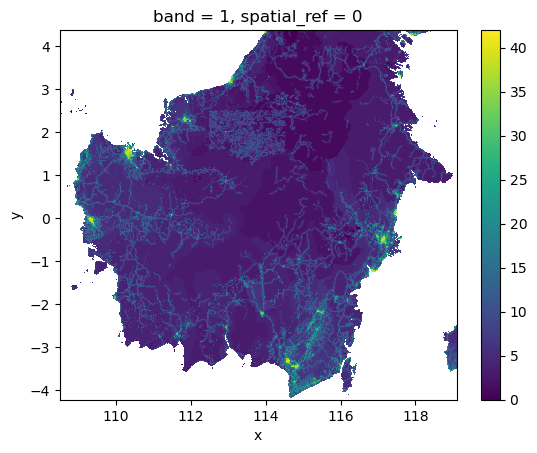

In [48]:
xr.where(hfp_kalimantan == 255, np.nan, hfp_kalimantan).plot()

In [49]:
hfp_kalimantan.rio.to_raster('output-data/predictor-layers/hfp.tif')

## Elevation & slope

In [53]:
# open data
elevation_global = rxr.open_rasterio('input-data/elevation/dtm_elevation_merit.dem_m_250m_s0..0cm_2017_v1.0.tif')

In [54]:
# crop
elevation = sel_bounds(elevation_global, study_area)

In [56]:
# reproject match
elevation_reproj = elevation.rio.reproject_match(study_area, resampling=Resampling.bilinear)

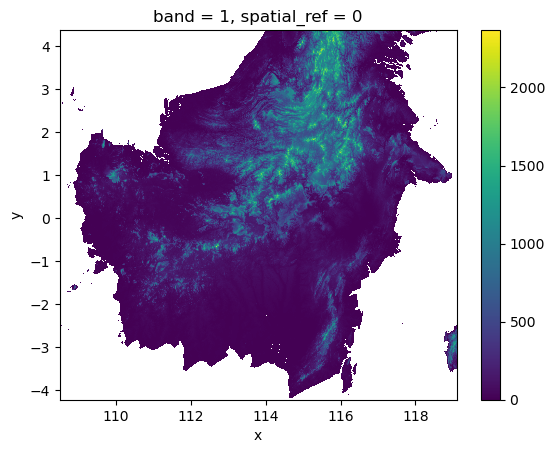

In [61]:
xr.where(elevation_reproj < 0, np.nan, elevation_reproj).plot()

In [62]:
# export
elevation_reproj.rio.to_raster('output-data/predictor-layers/elevation.tif')

## Burn severity (dNBR)

exported pre- and post-fire NIR and SWIR (3-month composites) from Landsat Surface Reflectance (MOD09A1)

In [67]:
# load layers
pre_SR = rxr.open_rasterio('input-data/MODIS-exports/MODIS_SR_pre_fire.tif')
post_SR = rxr.open_rasterio('input-data/MODIS-exports/MODIS_SR_post_fire.tif')

# split into bands, resample to match grid, apply scale factor (values saved as integers)
pre_nir = pre_SR.sel(band=1).rio.reproject_match(study_area, resampling=Resampling.bilinear) * 0.0001
pre_swir = pre_SR.sel(band=2).rio.reproject_match(study_area, resampling=Resampling.bilinear) * 0.0001
post_nir = post_SR.sel(band=1).rio.reproject_match(study_area, resampling=Resampling.bilinear) * 0.0001
post_swir = post_SR.sel(band=2).rio.reproject_match(study_area, resampling=Resampling.bilinear) * 0.0001

In [78]:
# calculate NBR
pre_nbr = (pre_nir - pre_swir) / (pre_nir + pre_swir)
post_nbr = (post_nir - post_swir) / (post_nir + post_swir)

# mask to keep only values in normal range
pre_nbr = xr.where(
    (pre_nbr > -1.5) & (pre_nbr < 1.5),
    pre_nbr, np.nan)
post_nbr = xr.where(
    (post_nbr > -1.5) & (post_nbr < 1.5),
    post_nbr, np.nan)

# calculate difference
dnbr = pre_nbr - post_nbr

(array([  33.,  313., 1338., 2943., 4171., 4157., 2818., 1429.,  693.,
          94.]),
 array([-0.26564072, -0.1538817 , -0.04212267,  0.06963636,  0.18139539,
         0.29315442,  0.40491345,  0.51667248,  0.6284315 ,  0.74019053,
         0.85194956]),
 <BarContainer object of 10 artists>)

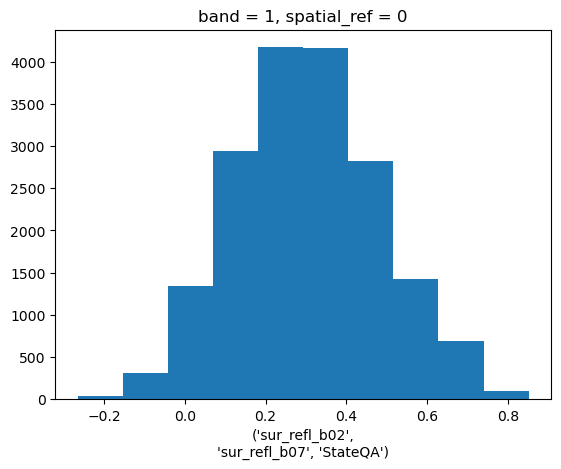

In [81]:
xr.where(study_area, dnbr, np.nan).plot.hist()

In [83]:
# remove attribute that prevents export
del dnbr.attrs['long_name']

In [84]:
# export 
dnbr.rio.to_raster('output-data/predictor-layers/dnbr.tif')